In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os

import seaborn as sns



# Load data

In [3]:
# Load barcode dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [4]:
entropy_peak_cluster_file = os.path.join(Union_cell_subdir, "Entropy_cells_peaks", "DownstreamReanalysis", "union_3set_Entropypeaks_cluster.tsv")
tss_peak_cluster_file = os.path.join(Union_cell_subdir, "TSS_cells_peaks", "DownstreamReanalysis", "union_3set_TSSpeaks_cluster.tsv")
frip_peak_cluster_file = os.path.join(Union_cell_subdir, "FRIP_cells_peaks", "DownstreamReanalysis", "union_3set_FRIPpeaks_cluster.tsv")

entropy_peak_cluster = pd.read_csv(entropy_peak_cluster_file, sep='\t', index_col=1)
tss_peak_cluster = pd.read_csv(tss_peak_cluster_file, sep='\t', index_col=1)
frip_peak_cluster = pd.read_csv(frip_peak_cluster_file, sep='\t', index_col=1)

In [5]:
frip_peak_cluster.head(2)

,barcodes,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,...,log10_total_frag,_scvi_batch,_scvi_labels,clusters_peakvi_FRIPpeaks_unionBC,MT%,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,leiden_RNA_scVI_unionBC,good_cluster
atac_barcodes,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,...,3.382377,0,0,5,13.120394,7.618742,1147.0,267.0,3,True
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,...,3.955688,0,0,3,26.166204,8.082711,1531.0,847.0,0,False


In [6]:
tss_peak_cluster.head(2)

,barcodes,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,...,log10_total_frag,_scvi_batch,_scvi_labels,clusters_peakvi_TSSpeaks_unionBC,MT%,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,leiden_RNA_scVI_unionBC,good_cluster
atac_barcodes,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,...,3.382377,0,0,1,13.120394,7.618742,1147.0,267.0,3,True
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,...,3.955688,0,0,5,26.166204,8.082711,1531.0,847.0,0,False


In [7]:
entropy_peak_cluster.head(2)

,barcodes,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,...,log10_total_frag,_scvi_batch,_scvi_labels,clusters_peakvi_Entropypeaks_unionBC,MT%,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,leiden_RNA_scVI_unionBC,good_cluster
atac_barcodes,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,...,3.382377,0,0,1,13.120394,7.618742,1147.0,267.0,3,True
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,...,3.955688,0,0,2,26.166204,8.082711,1531.0,847.0,0,True


In [8]:
for df, name in zip([entropy_peak_cluster, tss_peak_cluster, frip_peak_cluster], ["Entropypeaks", "TSSpeaks", "FRIPpeaks"]):
    union_cell_info[f"{name}_atac_cluster"] = union_cell_info.index.map(df['clusters_peakvi_' + name + '_unionBC'])
    union_cell_info[f"{name}_good_cluster"] = union_cell_info.index.map(df['good_cluster'])

union_cell_info['atac_universal_good_cluster'] = union_cell_info[['Entropypeaks_good_cluster', 'TSSpeaks_good_cluster', 'FRIPpeaks_good_cluster']].all(axis=1)

In [9]:
union_cell_info.groupby(['atac_universal_good_cluster', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
atac_universal_good_cluster,,
False,218,214
True,65,1887


In [10]:
union_cell_info.groupby(['atac_universal_good_cluster', 'atac_pass_archr_TSS']).size().unstack(fill_value=0)

atac_pass_archr_TSS,False,True
atac_universal_good_cluster,,
False,118,314
True,134,1818


In [11]:
union_cell_info.groupby(['atac_universal_good_cluster', 'atac_pass_CR']).size().unstack(fill_value=0)

atac_pass_CR,False,True
atac_universal_good_cluster,,
False,262,170
True,163,1789


In [12]:
union_cell_info.groupby(['atac_universal_good_cluster', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_universal_good_cluster,,
False,294,138
True,46,1906


## See qc stats on the universally good cluster cells 

In [13]:
# Load fragments file
frag_in_housekeeping_file = os.path.join(Union_cell_subdir, 'frag_in_housekeeping.bed')
frag_in_housekeeping = pd.read_csv(frag_in_housekeeping_file, sep='\t', index_col=3, header=None)
frag_in_housekeeping.index.name = 'atac_BC'
frag_in_housekeeping.columns = ['chrom', 'start', 'end', 'support', 'gene_chrom', 'gene_start', 'gene_end', 'gene_name', 'bp_overlap']
frag_in_housekeeping['atac_bc'] = frag_in_housekeeping.index.map(lambda x: x.split('-1')[0])
frag_in_housekeeping['frag_length'] = frag_in_housekeeping['end'] - frag_in_housekeeping['start']

frag_in_housekeeping.head(2)

,chrom,start,end,support,gene_chrom,gene_start,gene_end,gene_name,bp_overlap,atac_bc,frag_length
atac_BC,,,,,,,,,,,
GATTGCTGTGCGGTTC-1,chr1,1785095,1785410,1,chr1,1785285,1891117,GNB1,125,GATTGCTGTGCGGTTC,315
GCTTCATCATATGGTG-1,chr1,1785349,1785670,1,chr1,1785285,1891117,GNB1,321,GCTTCATCATATGGTG,321


In [14]:
total_frag_in_housekeeping = frag_in_housekeeping.groupby('atac_bc').size()
union_cell_info['total_frag_in_housekeeping'] = union_cell_info.index.map(total_frag_in_housekeeping).fillna(0).astype(int)

union_cell_info['HKG_frag_percent'] = union_cell_info['total_frag_in_housekeeping'] / union_cell_info['total_fragments']


Text(0.5, 1.0, 'Among union BCs')

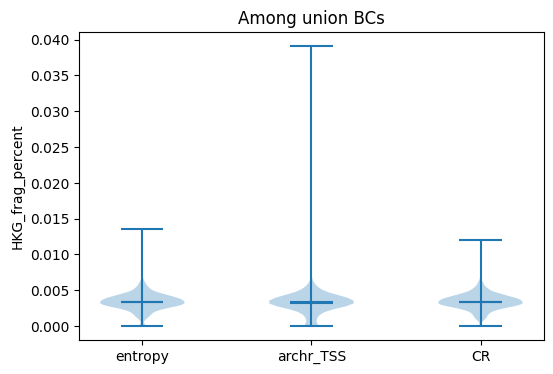

In [15]:
housekeeping_total_frag = [union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'HKG_frag_percent'], 
                           union_cell_info.loc[union_cell_info['atac_pass_archr_TSS'], 'HKG_frag_percent'], 
                           union_cell_info.loc[union_cell_info['atac_pass_CR'], 'HKG_frag_percent']]

fig, ax = plt.subplots(figsize=(6, 4))




_ = ax.violinplot(housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['entropy', 'archr_TSS', 'CR'])
ax.set_ylabel('HKG_frag_percent')
ax.set_title('Among union BCs')

In [17]:
for s in ['atac_pass_entropy', 'atac_pass_archr_TSS', 'atac_pass_CR']:
    print(f"{s}: {union_cell_info.loc[union_cell_info[s], 'HKG_frag_percent'].describe()}")
    print(f"------------")


atac_pass_entropy: count    2101.000000
mean        0.003412
std         0.001262
min         0.000000
25%         0.002753
50%         0.003390
75%         0.004077
max         0.013503
Name: HKG_frag_percent, dtype: float64
------------
atac_pass_archr_TSS: count    2132.000000
mean        0.003272
std         0.001679
min         0.000000
25%         0.002653
50%         0.003347
75%         0.004026
max         0.039085
Name: HKG_frag_percent, dtype: float64
------------
atac_pass_CR: count    1959.000000
mean        0.003426
std         0.001156
min         0.000000
25%         0.002794
50%         0.003397
75%         0.004057
max         0.012090
Name: HKG_frag_percent, dtype: float64
------------


In [23]:
union_cell_info.loc[union_cell_info['HKG_frag_percent'] > 0.014, ]

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,Entropypeaks_atac_cluster,Entropypeaks_good_cluster,TSSpeaks_atac_cluster,TSSpeaks_good_cluster,FRIPpeaks_atac_cluster,FRIPpeaks_good_cluster,atac_universal_good_cluster,total_frag_in_housekeeping,HKG_frag_percent
atac_bc,,,,,,,,,,,,,,,,,,,,
CCACAAACAACCTCGC,1054,False,False,True,none,tss_only,GGTACCGGTCAGGCAT,False,0.008509,4,NO,3,False,5,False,3,False,False,33,0.031309
GCAAATATCCCTCGTC,1043,False,False,True,none,tss_only,AGGATGCAGCATGTCG,False,0.009764,4,NO,3,False,2,True,3,False,False,17,0.016299
TTCGCGCCATAGACTG,1049,False,False,True,none,tss_only,GCTCATTGTGTTTGAG,False,0.007786,4,NO,3,False,5,False,3,False,False,41,0.039085


Text(0.5, 1.0, 'Among BCs in atac universally-good clusters')

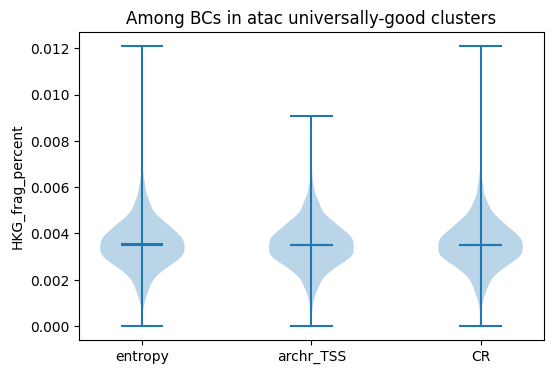

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))


df = union_cell_info.loc[union_cell_info['atac_universal_good_cluster']]

housekeeping_total_frag = [df.loc[df['atac_pass_entropy'], 'HKG_frag_percent'], 
                           df.loc[df['atac_pass_archr_TSS'], 'HKG_frag_percent'], 
                           df.loc[df['atac_pass_CR'], 'HKG_frag_percent']]

_ = ax.violinplot(housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['entropy', 'archr_TSS', 'CR'])
ax.set_ylabel('HKG_frag_percent')
ax.set_title('Among BCs in atac universally-good clusters')



Text(0.5, 1.0, 'All union BCs')

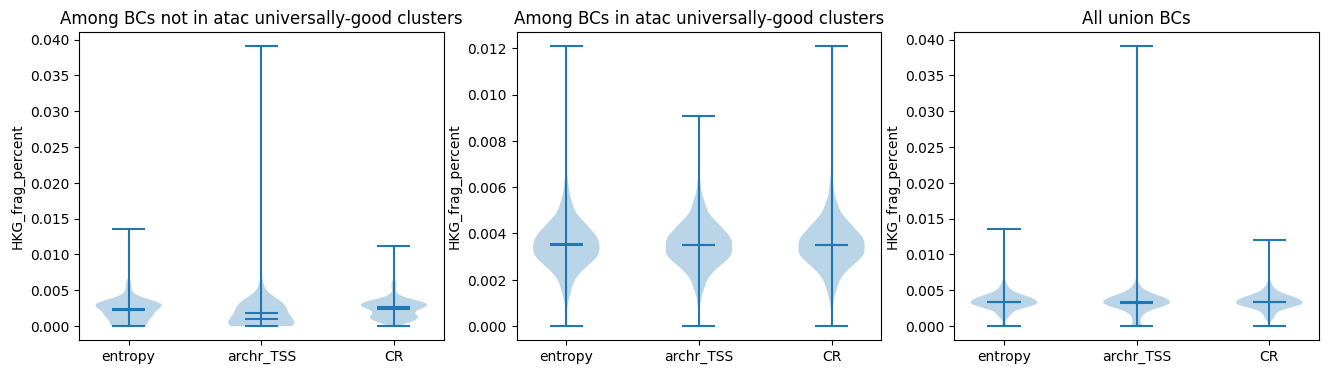

In [20]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 4),)


df_ = union_cell_info.loc[~union_cell_info['atac_universal_good_cluster']]

notgood_housekeeping_total_frag = [df_.loc[df_['atac_pass_entropy'], 'HKG_frag_percent'], 
                           df_.loc[df_['atac_pass_archr_TSS'], 'HKG_frag_percent'], 
                           df_.loc[df_['atac_pass_CR'], 'HKG_frag_percent']]

good_housekeeping_total_frag = [df.loc[df['atac_pass_entropy'], 'HKG_frag_percent'], 
                           df.loc[df['atac_pass_archr_TSS'], 'HKG_frag_percent'], 
                           df.loc[df['atac_pass_CR'], 'HKG_frag_percent']]

housekeeping_total_frag = [union_cell_info.loc[union_cell_info['atac_pass_entropy'], 'HKG_frag_percent'], 
                           union_cell_info.loc[union_cell_info['atac_pass_archr_TSS'], 'HKG_frag_percent'], 
                           union_cell_info.loc[union_cell_info['atac_pass_CR'], 'HKG_frag_percent']]

_ = ax[0].violinplot(notgood_housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)

_ = ax[1].violinplot(good_housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)

_ = ax[2].violinplot(housekeeping_total_frag, 
                  positions=[1, 2, 3], 
                  showmeans=True, showmedians=True)

for a in ax:
    a.set_xticks([1, 2, 3])
    a.set_xticklabels(['entropy', 'archr_TSS', 'CR'])
    a.set_ylabel('HKG_frag_percent')


ax[0].set_title('Among BCs not in atac universally-good clusters')
ax[1].set_title('Among BCs in atac universally-good clusters')
ax[2].set_title('All union BCs')

Text(0, 0.5, 'HKG_frag_percent')

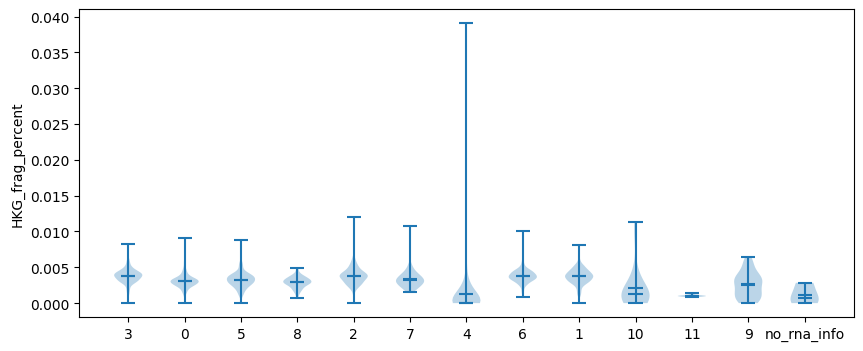

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))

RNA_clusters = union_cell_info['leiden_RNA_scVI'].unique()

housekeeping_total_frag = [union_cell_info.loc[union_cell_info['leiden_RNA_scVI'] == cluster, 'HKG_frag_percent'] for cluster in RNA_clusters]

x_pos = np.arange(len(RNA_clusters) )
_ = ax.violinplot(housekeeping_total_frag, 
                  positions=x_pos,
                  showmeans=True, showmedians=True)
ax.set_xticks(x_pos)
ax.set_xticklabels(RNA_clusters)
ax.set_ylabel('HKG_frag_percent')


In [99]:
reasonable_RNA_clusters = ['0', '1', '2', '3',  '5', '6', '7', '8']

union_cell_info.loc[union_cell_info['leiden_RNA_scVI'].isin(reasonable_RNA_clusters), 'HKG_frag_percent'].describe()   

count    2035.000000
mean        0.003485
std         0.001146
min         0.000000
25%         0.002810
50%         0.003431
75%         0.004095
max         0.012090
Name: HKG_frag_percent, dtype: float64

In [103]:
union_cell_info['sufficient_HKG_frag'] = union_cell_info['HKG_frag_percent'] > 0.002
union_cell_info.groupby(['atac_pass_entropy', 'sufficient_HKG_frag']).size().unstack(fill_value=0)

sufficient_HKG_frag,False,True
atac_pass_entropy,,
False,220,63
True,215,1886


In [104]:
union_cell_info.groupby(['atac_pass_archr_TSS', 'sufficient_HKG_frag']).size().unstack(fill_value=0)

sufficient_HKG_frag,False,True
atac_pass_archr_TSS,,
False,135,117
True,300,1832


In [105]:
union_cell_info.groupby(['atac_pass_CR', 'sufficient_HKG_frag']).size().unstack(fill_value=0)

sufficient_HKG_frag,False,True
atac_pass_CR,,
False,255,170
True,180,1779
